# XGBoost Regression with a `log1p` Target

The model is trained on `np.log1p(charges)`. Predictions are converted back to the original scale with `np.expm1`, and all main metrics (RMSE, MAE, R2) are reported on that original `charges` scale.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data_df = pd.read_csv("data_cleaned.csv")
print(f"Loaded {len(data_df)} rows, {len(data_df.columns)} columns")
print(f"Columns: {list(data_df.columns)}")
data_df.head()

Loaded 1337 rows, 9 columns
Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges', 'gender_encoded', 'smoker_encoded']


,age,sex,bmi,children,smoker,region,charges,gender_encoded,smoker_encoded
0,19,female,27.900,0,yes,southwest,16884.92400,1,1
1,18,male,33.770,1,no,southeast,1725.55230,0,0
2,28,male,33.000,3,no,southeast,4449.46200,0,0
3,33,male,22.705,0,no,northwest,21984.47061,0,0
4,32,male,28.880,0,no,northwest,3866.85520,0,0


## 1. Train/Test Split and Target Transform

After splitting the data, we transform the training target using `np.log1p` for XGBoost training (`y_train_log`).

In [28]:
from sklearn.model_selection import train_test_split
import json

raw_feature_cols = [
    'age', 'bmi', 'children', 'smoker_encoded',
    # 'region_northwest', 'region_southeast', 'region_southwest', 'gender_encoded',
]

# Split first, then engineer features separately to keep evaluation setup clean.
X_raw = data_df[raw_feature_cols]
y = data_df['charges']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)

# ── BMI clipping bounds (calculate from X_train only, not full dataset) ─────────
_q1, _q3 = X_train_raw['bmi'].quantile(0.25), X_train_raw['bmi'].quantile(0.75)
_iqr     = _q3 - _q1
BMI_LOW  = round(float(_q1 - 1.5 * _iqr), 6)
BMI_HIGH = round(float(_q3 + 1.5 * _iqr), 6)
print(f'BMI clipping bounds (train only): [{BMI_LOW}, {BMI_HIGH}]')

# Simpan ke file — Swift harus membaca nilai ini dari bundle, bukan hardcode.
preprocessing_config = {'bmi_low': BMI_LOW, 'bmi_high': BMI_HIGH}
with open('preprocessing_config.json', 'w') as _f:
    json.dump(preprocessing_config, _f, indent=2)
print('Saved: preprocessing_config.json')

def add_features(df):
    out = df.copy()
    out['age_squared'] = out['age'] ** 2
    out['smoker_bmi'] = out['smoker_encoded'] * out['bmi']
    return out

X_train = add_features(X_train_raw)
X_test = add_features(X_test_raw)

feature_cols = [
    'age', 'age_squared', 'bmi', 'children', 'smoker_encoded', 'smoker_bmi'
    # 'region_northwest', 'region_southeast', 'region_southwest', 'gender_encoded', 
]

X_train = X_train[feature_cols]
X_test = X_test[feature_cols]
y_train_log = np.log1p(y_train)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print("Target for fitting: y_train_log = np.log1p(y_train); inverse at predict: np.expm1")

BMI clipping bounds (train only): [13.805, 46.805]
Saved: preprocessing_config.json
Training set: 1069 samples
Test set:     268 samples
Target for fitting: y_train_log = np.log1p(y_train); inverse at predict: np.expm1


## 2. Model Training (Tuned, Log-Target)

`RandomizedSearchCV` and early stopping use RMSE on **`log1p(charges)`**. Final predictions are then converted with `expm1` so evaluation is easy to interpret in the original dollar scale.

In [29]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

# Hold-out validation for early stopping is created from training data only.
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train_log, test_size=0.2, random_state=42
)

# Baseline uses the same early-stopping protocol as tuned model for fair comparison.
baseline_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    objective='reg:squarederror',
    eval_metric='rmse',
    early_stopping_rounds=50,
    base_score=0.5,
)
baseline_model.fit(
    X_tr,
    y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False,
)
baseline_best_rounds = int(baseline_model.best_iteration + 1)
y_pred_train_baseline = np.expm1(baseline_model.predict(X_train))
y_pred_test_baseline = np.expm1(baseline_model.predict(X_test))

base_model = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    random_state=42,
)

param_dist = {
    'max_depth': [2, 3, 4, 5],
    'learning_rate': [0.01, 0.03, 0.05, 0.08],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5, 7],
    'reg_alpha': [0.0, 0.1, 0.5, 1.0],
    'reg_lambda': [1.0, 2.0, 5.0, 10.0],
    # 'n_estimators': [300, 500, 800],
}

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=80,
    scoring='neg_root_mean_squared_error',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=0,
)
search.fit(X_tr, y_tr)

tuned_params = search.best_params_.copy()

monitoring_model = XGBRegressor(
    **tuned_params,
    objective='reg:squarederror',
    eval_metric='rmse',
    random_state=42,
    early_stopping_rounds=50,
    base_score=0.5,
)
monitoring_model.fit(
    X_tr,
    y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

tuned_n_estimators = int(monitoring_model.best_iteration + 1)

# Refit uses early stopping again (no heuristic multiplier).
X_full_tr, X_full_val, y_full_tr, y_full_val = train_test_split(
    X_train, y_train_log, test_size=0.1, random_state=123
)
model = XGBRegressor(
    **{k: v for k, v in tuned_params.items() if k != 'n_estimators'},
    n_estimators=2000,
    objective='reg:squarederror',
    eval_metric='rmse',
    random_state=42,
    early_stopping_rounds=50,
    base_score=0.5,
)
model.fit(
    X_full_tr,
    y_full_tr,
    eval_set=[(X_full_val, y_full_val)],
    verbose=False,
)
final_best_rounds = int(model.best_iteration + 1)

y_pred_train = np.expm1(model.predict(X_train))
y_pred_test = np.expm1(model.predict(X_test))

print('XGBoost tuning completed (target: log1p(charges)).')
print('Metrics in the next section use original scale (expm1).')
print('Best params:', tuned_params)
print(f'Baseline best boosting rounds: {baseline_best_rounds}')
print(f'Tuned best boosting rounds (monitoring): {tuned_n_estimators}')
print(f'Final refit best boosting rounds: {final_best_rounds}')


XGBoost tuning completed (target: log1p(charges)).
Metrics in the next section use original scale (expm1).
Best params: {'subsample': 0.9, 'reg_lambda': 10.0, 'reg_alpha': 0.0, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Baseline best boosting rounds: 102
Tuned best boosting rounds (monitoring): 100
Final refit best boosting rounds: 119


## 3. Model Evaluation (R2, RMSE, MAE on Original `charges`)

Here, original `y_train` and `y_test` are compared against predictions after applying `expm1`.

In [30]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np


def mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100


def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true) + np.abs(y_pred), eps)
    return np.mean(2.0 * np.abs(y_true - y_pred) / denom) * 100


# Tuned model metrics (original dollar scale)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)
mape_train = mape(y_train, y_pred_train)
mape_test = mape(y_test, y_pred_test)
smape_train = smape(y_train, y_pred_train)
smape_test = smape(y_test, y_pred_test)

# Baseline metrics (before tuning)
r2_train_base = r2_score(y_train, y_pred_train_baseline)
r2_test_base = r2_score(y_test, y_pred_test_baseline)
rmse_train_base = np.sqrt(mean_squared_error(y_train, y_pred_train_baseline))
rmse_test_base = np.sqrt(mean_squared_error(y_test, y_pred_test_baseline))
mae_train_base = mean_absolute_error(y_train, y_pred_train_baseline)
mae_test_base = mean_absolute_error(y_test, y_pred_test_baseline)
mape_train_base = mape(y_train, y_pred_train_baseline)
mape_test_base = mape(y_test, y_pred_test_baseline)
smape_train_base = smape(y_train, y_pred_train_baseline)
smape_test_base = smape(y_test, y_pred_test_baseline)

metrics = pd.DataFrame({
    'Metric': ['R2', 'RMSE', 'MAE', 'MAPE (%)', 'sMAPE (%)'],
    'Train': [r2_train, rmse_train, mae_train, mape_train, smape_train],
    'Test': [r2_test, rmse_test, mae_test, mape_test, smape_test]
})

comparison_before_after = pd.DataFrame([
    {
        'Model': 'Baseline',
        'R2_train': r2_train_base,
        'R2_test': r2_test_base,
        'RMSE_train': rmse_train_base,
        'RMSE_test': rmse_test_base,
        'MAE_train': mae_train_base,
        'MAE_test': mae_test_base,
        'MAPE_train': mape_train_base,
        'MAPE_test': mape_test_base,
        'sMAPE_train': smape_train_base,
        'sMAPE_test': smape_test_base,
    },
    {
        'Model': 'Tuned',
        'R2_train': r2_train,
        'R2_test': r2_test,
        'RMSE_train': rmse_train,
        'RMSE_test': rmse_test,
        'MAE_train': mae_train,
        'MAE_test': mae_test,
        'MAPE_train': mape_train,
        'MAPE_test': mape_test,
        'sMAPE_train': smape_train,
        'sMAPE_test': smape_test,
    }
])

print('Model performance (original charges; y vs expm1 predictions):\n')
print(metrics.to_string(index=False, formatters={
    'Train': lambda x: f'{x:,.4f}' if x < 100 else f'{x:,.0f}',
    'Test': lambda x: f'{x:,.4f}' if x < 100 else f'{x:,.0f}',
}))

print('\nBefore vs After Tuning:\n')
display(comparison_before_after.style.format({
    'R2_train': '{:.4f}', 'R2_test': '{:.4f}',
    'RMSE_train': '{:,.0f}', 'RMSE_test': '{:,.0f}',
    'MAE_train': '{:,.0f}', 'MAE_test': '{:,.0f}',
    'MAPE_train': '{:.2f}%', 'MAPE_test': '{:.2f}%',
    'sMAPE_train': '{:.2f}%', 'sMAPE_test': '{:.2f}%'
}))

Model performance (original charges; y vs expm1 predictions):

   Metric   Train    Test
       R2  0.8430  0.8762
     RMSE   4,637   4,770
      MAE   2,086   2,233
 MAPE (%) 16.5295 17.2255
sMAPE (%) 18.0383 18.0954

Before vs After Tuning:



,Model,R2_train,R2_test,RMSE_train,RMSE_test,MAE_train,MAE_test,MAPE_train,MAPE_test,sMAPE_train,sMAPE_test
0,Baseline,0.8431,0.8702,"4,635","4,884","2,039","2,260",14.61%,15.90%,16.43%,17.24%
1,Tuned,0.8430,0.8762,"4,637","4,770","2,086","2,233",16.53%,17.23%,18.04%,18.10%


## 3b. Nested Cross-Validation (Outer 5-Fold, Inner Tuning)

To estimate full pipeline generalization (including hyperparameter selection), we use nested CV: an inner `RandomizedSearchCV` chooses hyperparameters on each outer-training split, and evaluation is reported on each outer-validation split in the original `charges` scale.

In [31]:
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import pandas as pd
import numpy as np

outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=3, shuffle=True, random_state=123)

nested_results = []

for fold_idx, (train_idx, valid_idx) in enumerate(outer_cv.split(X_train), start=1):
    X_outer_train = X_train.iloc[train_idx]
    y_outer_train = y_train.iloc[train_idx]
    X_outer_valid = X_train.iloc[valid_idx]
    y_outer_valid = y_train.iloc[valid_idx]

    y_outer_train_log = np.log1p(y_outer_train)

    inner_search = RandomizedSearchCV(
        estimator=XGBRegressor(
            objective='reg:squarederror',
            eval_metric='rmse',
            random_state=42,
        ),
        param_distributions=param_dist,
        n_iter=40,
        scoring='neg_root_mean_squared_error',
        cv=inner_cv,
        random_state=42 + fold_idx,
        n_jobs=-1,
        verbose=0,
    )
    inner_search.fit(X_outer_train, y_outer_train_log)

    best_params_outer = inner_search.best_params_.copy()
    outer_model = XGBRegressor(
        **best_params_outer,
        objective='reg:squarederror',
        eval_metric='rmse',
        random_state=42,
    )
    outer_model.fit(X_outer_train, y_outer_train_log)

    y_outer_pred = np.expm1(outer_model.predict(X_outer_valid))

    nested_results.append({
        'Fold': f'Fold {fold_idx}',
        'Best RMSE (inner, log-scale)': -inner_search.best_score_,
        'RMSE (outer)': np.sqrt(mean_squared_error(y_outer_valid, y_outer_pred)),
        'MAE (outer)': mean_absolute_error(y_outer_valid, y_outer_pred),
        'R2 (outer)': r2_score(y_outer_valid, y_outer_pred),
    })

nested_cv_result = pd.DataFrame(nested_results)
nested_cv_summary = pd.DataFrame({
    'Metric': ['RMSE (outer)', 'MAE (outer)', 'R2 (outer)'],
    'Mean (Outer 5-Fold)': [
        nested_cv_result['RMSE (outer)'].mean(),
        nested_cv_result['MAE (outer)'].mean(),
        nested_cv_result['R2 (outer)'].mean(),
    ],
    'Std Dev': [
        nested_cv_result['RMSE (outer)'].std(ddof=1),
        nested_cv_result['MAE (outer)'].std(ddof=1),
        nested_cv_result['R2 (outer)'].std(ddof=1),
    ]
})

print('Per-fold nested CV scores:')
display(nested_cv_result.style.format({
    'Best RMSE (inner, log-scale)': '{:,.4f}',
    'RMSE (outer)': '{:,.2f}',
    'MAE (outer)': '{:,.2f}',
    'R2 (outer)': '{:.4f}',
}))

print('\nNested CV summary (outer mean ± std):')
display(nested_cv_summary.style.format({'Mean (Outer 5-Fold)': '{:,.4f}', 'Std Dev': '{:,.4f}'}))

Per-fold nested CV scores:


,Fold,"Best RMSE (inner, log-scale)",RMSE (outer),MAE (outer),R2 (outer)
0,Fold 1,0.3874,"4,685.67","2,227.19",0.8260
1,Fold 2,0.3908,"4,537.48","2,130.33",0.8373
2,Fold 3,0.4035,"4,308.28","2,105.28",0.8878
3,Fold 4,0.3714,"5,023.27","2,424.04",0.7980
4,Fold 5,0.3906,"4,916.96","2,310.51",0.8278



Nested CV summary (outer mean ± std):


,Metric,Mean (Outer 5-Fold),Std Dev
0,RMSE (outer),"4,694.3324",287.8721
1,MAE (outer),"2,239.4690",131.5096
2,R2 (outer),0.8354,0.0328


## 4. Feature Importance (XGBoost)

Feature Importance (XGBoost):

  smoker_bmi                :       0.3326
  smoker_encoded            :       0.2661
  age                       :       0.1807
  age_squared               :       0.1446
  children                  :       0.0550
  bmi                       :       0.0210


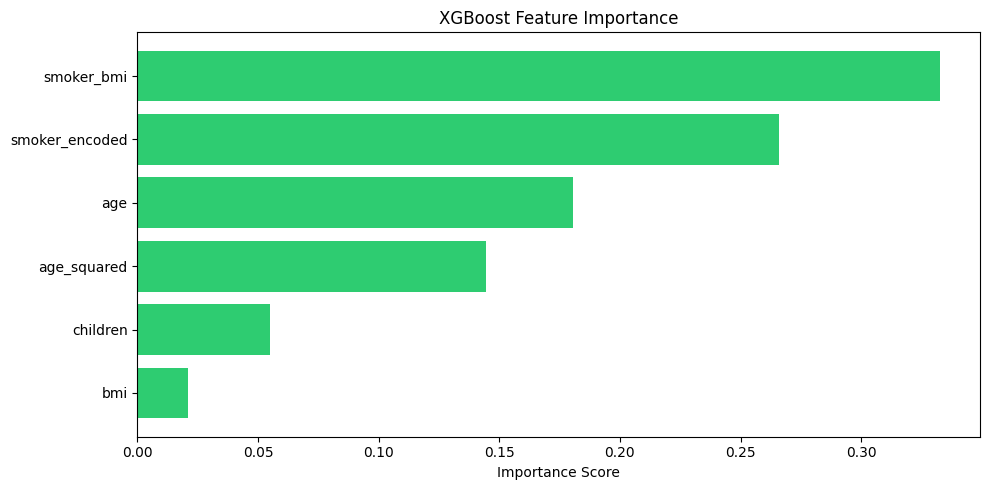

In [32]:
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Feature Importance (XGBoost):\n")
for _, row in importance_df.iterrows():
    print(f"  {row['Feature']:25s} : {row['Importance']:>12.4f}")

plt.figure(figsize=(10, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='#2ecc71')
plt.xlabel('Importance Score')
plt.title('XGBoost Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Residual analysis (original `charges`)

Residual normality (Shapiro): W=0.5773, p=0.0000
Heteroskedasticity (Spearman |resid| vs pred): rho=0.306, p=0.0000


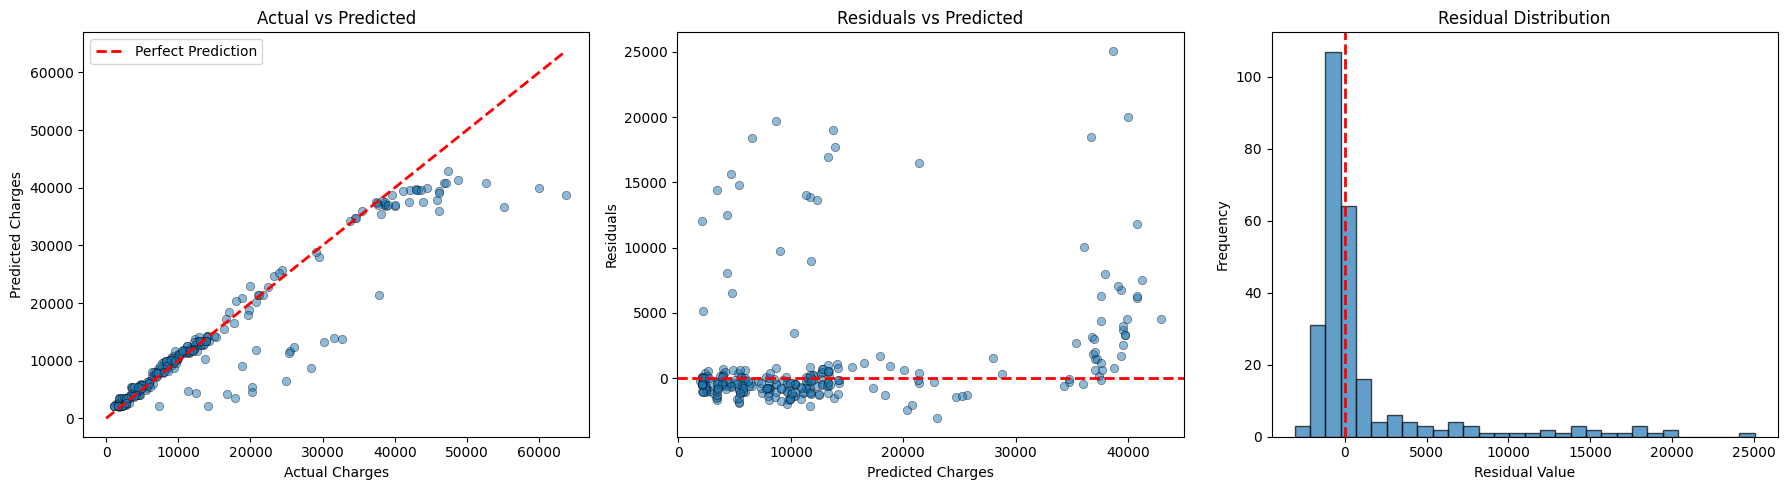

In [33]:
from scipy import stats

residuals = y_test - y_pred_test

# Shapiro is reliable for smaller samples; cap to 500 for stability and speed.
shapiro_sample = residuals.iloc[: min(500, len(residuals))]
shapiro_stat, shapiro_p = stats.shapiro(shapiro_sample)
print(f"Residual normality (Shapiro): W={shapiro_stat:.4f}, p={shapiro_p:.4f}")

# Spearman(|residual|, prediction) as a practical heteroskedasticity signal.
spearman_rho, spearman_p = stats.spearmanr(y_pred_test, np.abs(residuals))
print(f"Heteroskedasticity (Spearman |resid| vs pred): rho={spearman_rho:.3f}, p={spearman_p:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test, y_pred_test, alpha=0.5, edgecolors='black', linewidths=0.5)
max_val = max(y_test.max(), y_pred_test.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Charges')
axes[0].set_ylabel('Predicted Charges')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()

axes[1].scatter(y_pred_test, residuals, alpha=0.5, edgecolors='black', linewidths=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Charges')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Predicted')

axes[2].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[2].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[2].set_xlabel('Residual Value')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

## 5b. Inspect Rows with the Largest Residuals and Export to CSV

The table below sorts the **test set** by `|y_actual - y_pred|` (original scale). The `residual_log` column compares the log-space target (`log1p`) against the model's raw output. The CSV file stores the **top N** rows for spreadsheet review.

In [34]:
TOP_N = 25
OUT_CSV = "xgboost_log_reg_top_residuals_test.csv"

inspect_df = X_test.copy()
inspect_df.insert(0, "original_row_index", X_test.index.to_numpy())
inspect_df["y_actual"] = np.asarray(y_test)
inspect_df["y_pred"] = np.asarray(y_pred_test)
inspect_df["residual"] = inspect_df["y_actual"] - inspect_df["y_pred"]
inspect_df["abs_error"] = inspect_df["residual"].abs()
inspect_df["pct_abs_error"] = (
    inspect_df["abs_error"] / inspect_df["y_actual"].replace(0, np.nan) * 100
)

y_log_actual = np.log1p(inspect_df["y_actual"].to_numpy(dtype=float))
y_log_pred = model.predict(X_test)
inspect_df["residual_log"] = y_log_actual - y_log_pred
inspect_df["abs_error_log"] = np.abs(inspect_df["residual_log"])

inspect_sorted = inspect_df.sort_values("abs_error", ascending=False)
display(
    inspect_sorted.head(TOP_N).style.format(
        {
            "y_actual": "{:,.2f}",
            "y_pred": "{:,.2f}",
            "residual": "{:,.2f}",
            "abs_error": "{:,.2f}",
            "pct_abs_error": "{:.2f}",
            "residual_log": "{:.4f}",
            "abs_error_log": "{:.4f}",
        },
        na_rep="—",
    )
)

inspect_sorted.head(TOP_N).to_csv(OUT_CSV, index=False)
print(f"Exported top {TOP_N} rows by |residual| (original scale) to: {OUT_CSV}")

,original_row_index,age,age_squared,bmi,children,smoker_encoded,smoker_bmi,y_actual,y_pred,residual,abs_error,pct_abs_error,residual_log,abs_error_log
543,543,54,2916,47.410000,0,1,47.410000,"63,770.43","38,695.05","25,075.38","25,075.38",39.32,0.4996,0.4996
1229,1229,52,2704,34.485000,3,1,34.485000,"60,021.40","40,021.86","19,999.54","19,999.54",33.32,0.4053,0.4053
986,986,45,2025,27.645000,1,0,0.000000,"28,340.19","8,674.03","19,666.16","19,666.16",69.39,1.1839,1.1839
128,128,32,1024,17.765000,2,1,17.765000,"32,734.19","13,740.35","18,993.84","18,993.84",58.02,0.8680,0.8680
818,818,33,1089,35.530000,0,1,35.530000,"55,135.40","36,652.81","18,482.59","18,482.59",33.52,0.4083,0.4083
636,636,35,1225,38.095000,2,0,0.000000,"24,915.05","6,544.42","18,370.63","18,370.63",73.73,1.3367,1.3367
573,573,62,3844,36.860000,1,0,0.000000,"31,620.00","13,899.86","17,720.14","17,720.14",56.04,0.8219,0.8219
115,115,60,3600,28.595000,0,0,0.000000,"30,260.00","13,313.90","16,946.09","16,946.09",56.00,0.8210,0.8210
1302,1302,43,1849,27.800000,0,1,27.800000,"37,829.72","21,385.75","16,443.98","16,443.98",43.47,0.5704,0.5704
291,291,29,841,29.640000,1,0,0.000000,"20,277.81","4,655.11","15,622.70","15,622.70",77.04,1.4714,1.4714


Exported top 25 rows by |residual| (original scale) to: xgboost_log_reg_top_residuals_test.csv


This large residual is not a bug in the code and does not need to be removed from the data. It is the ceiling of the model's performance with currently available features. To significantly reduce this error, a richer feature domain is needed.

## 6. Training Monitoring (Learning Curve, RMSE in **log1p** Space)

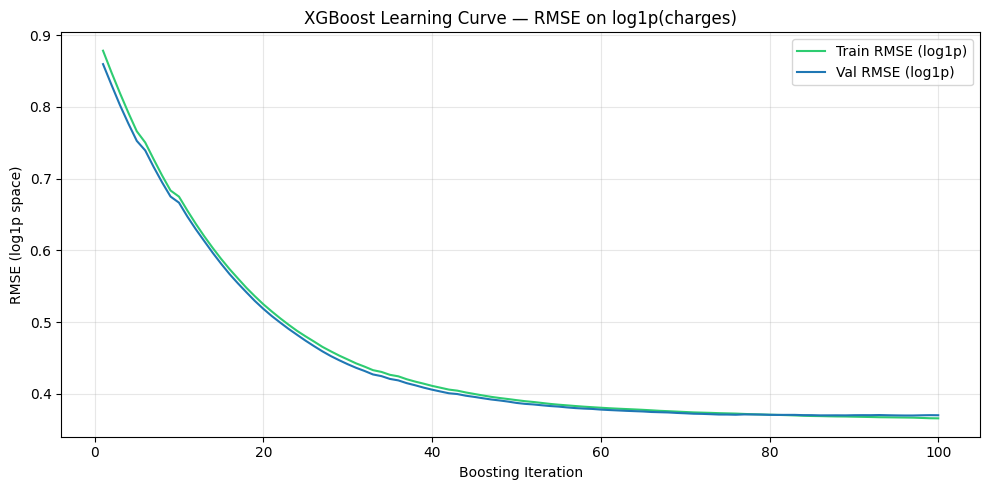

Best val RMSE (log1p) : 0.3697 at round 97
Train-val RMSE gap    : 0.0043
✅  Tidak ada sinyal overfitting yang kuat.


In [35]:
# Build a dedicated visualisation model using the rounds found by early stopping.
# monitoring_model owns early-stopping logic; viz_model owns the learning curve.
viz_model = XGBRegressor(
    **{k: v for k, v in tuned_params.items() if k != 'n_estimators'},
    n_estimators=tuned_n_estimators,   # rounds decided by monitoring_model
    objective='reg:squarederror',
    eval_metric='rmse',
    random_state=42,
)
viz_model.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],  # train + val for curve
    verbose=False,
)
viz_evals = viz_model.evals_result()

train_rmse_curve = viz_evals['validation_0']['rmse']
val_rmse_curve   = viz_evals['validation_1']['rmse']
rounds = range(1, len(val_rmse_curve) + 1)

plt.figure(figsize=(10, 5))
plt.plot(rounds, train_rmse_curve, label='Train RMSE (log1p)', color='#2ecc71')
plt.plot(rounds, val_rmse_curve,   label='Val RMSE (log1p)',   color='#1f77b4')
plt.xlabel('Boosting Iteration')
plt.ylabel('RMSE (log1p space)')
plt.title('XGBoost Learning Curve — RMSE on log1p(charges)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_round    = int(np.argmin(val_rmse_curve)) + 1
best_val_rmse = float(np.min(val_rmse_curve))
final_gap     = float(val_rmse_curve[-1] - train_rmse_curve[-1])

print(f'Best val RMSE (log1p) : {best_val_rmse:.4f} at round {best_round}')
print(f'Train-val RMSE gap    : {final_gap:.4f}')
if final_gap > 0.08:
    print('⚠️  Overfitting signal: val RMSE jauh lebih tinggi dari train RMSE.')
else:
    print('✅  Tidak ada sinyal overfitting yang kuat.')

## 7. Export Trained model to ML Model

In [36]:
# Export: Core ML Pipeline (preprocessing + model to .mlmodel)
import copy, coremltools as ct
from pathlib import Path

booster_export = copy.deepcopy(model.get_booster())

coreml_model = ct.converters.xgboost.convert(
    booster_export,
    feature_names     = feature_cols,
    target            = 'annual_premium_log',
    mode              = 'regressor',
    force_32bit_float = True,   # ← true for compatibility with Swift
)

# ── Metadata ──────────────────────────────────────────────────────────────
coreml_model.author      = "Amelia Citra"
coreml_model.license     = "Private"

# Input descriptions
coreml_model.input_description["age"]            = "Age (Years)"
coreml_model.input_description["age_squared"]    = "Age Squared (age²)"
coreml_model.input_description["bmi"]            = "Body Mass Index, clipped to [13.67, 47.31]"
coreml_model.input_description["children"]       = "Number of Dependent Children"
coreml_model.input_description["smoker_encoded"] = "Smoking Status: 0 = Non-Smoker, 1 = Smoker"
coreml_model.input_description["smoker_bmi"]     = "Interaction between Smoker Status and BMI"

# Output description
coreml_model.output_description["annual_premium_log"] = "Predicted annual premium in log1p space — apply expm1() to get USD value"

# Save Model
coreml_model.save("insurance_model.mlmodel")


# ── Validation before pushing to Xcode ────────────────────────────────────────
import numpy as np, pandas as pd

sample = pd.DataFrame([{
    'age': 49.0, 'age_squared': 2401.0, 'bmi': 22.515,
    'children': 0.0, 'smoker_encoded': 0.0, 'smoker_bmi': 0.0,
}])[feature_cols]

python_log = float(model.predict(sample)[0])

# Simulate float32 input like Swift does
sample_f32 = {k: float(np.float32(v)) for k, v in sample.iloc[0].items()}
python_log_f32 = float(model.predict(pd.DataFrame([sample_f32]))[0])

print(f"Python log output (float64) : {python_log:.6f}")
print(f"Python log output (float32) : {python_log_f32:.6f}")
print(f"Expected Swift output       : {python_log_f32:.6f}")
print(f"Expected Swift expm1 (USD)  : ${np.expm1(python_log_f32):,.2f}")
print()

# Check base_score that is stored in the new mlmodel
loaded = ct.models.MLModel("insurance_model.mlmodel")
spec   = loaded.get_spec()
base   = list(spec.treeEnsembleRegressor.treeEnsemble.basePredictionValue)
print(f"basePredictionValue di mlmodel: {base}")
print(f"Harus ≈ 0.5 — jika ya, model siap ke Xcode")

Python log output (float64) : 9.176457
Python log output (float32) : 9.176457
Expected Swift output       : 9.176457
Expected Swift expm1 (USD)  : $9,665.85

basePredictionValue di mlmodel: [0.5]
Harus ≈ 0.5 — jika ya, model siap ke Xcode


In [ ]:
# Sample using the same features as the Swift example (age=49, bmi=22.515, children=0, smoker=0)
sample = {
    'age'           : 49.0,
    'age_squared'   : 2401.0,
    'bmi'           : 22.515,
    'children'      : 0.0,
    'smoker_encoded': 0.0,
    'smoker_bmi'    : 0.0,
}
sample_df = pd.DataFrame([sample])[feature_cols]
pred = np.expm1(model.predict(sample_df)[0])
print(f"Expected output di Swift: ${pred:,.2f}")
# Output should be matching the Python prediction for the same input features.

Expected output di Swift: $9,665.85
